In [1]:
from afm_lib.graphs.grid_search import build_grid_search_graph
from afm_lib.schemas.recipe import load_recipe, site_program

from IPython.display import Image


In [2]:
recipe = load_recipe(r"../recipes/smoke_2site_ac.yaml")
graph  = build_grid_search_graph()

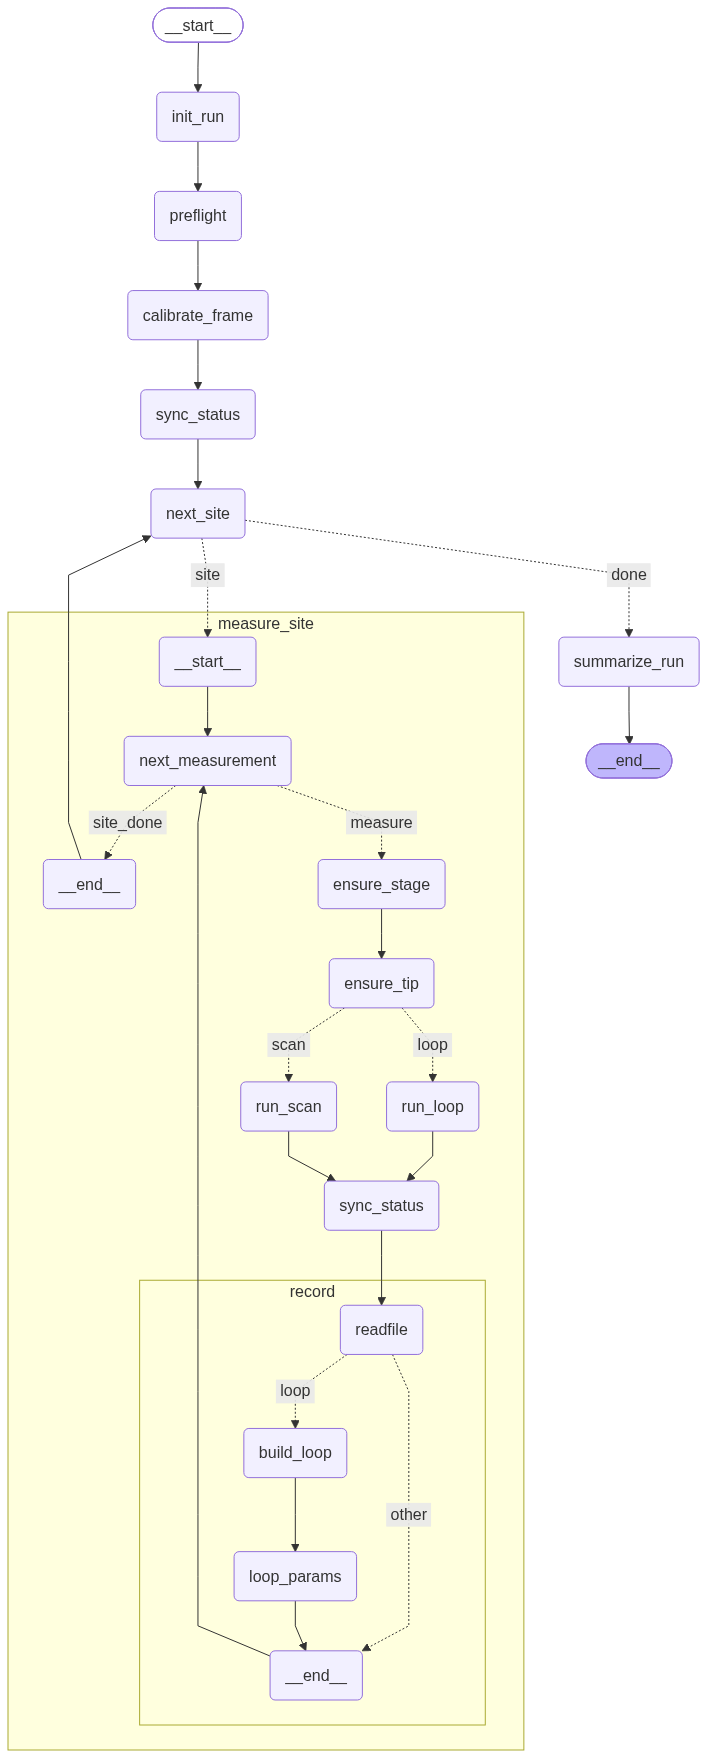

In [3]:

Image(graph.get_graph(xray=True).draw_mermaid_png())

In [4]:
n_meas = len(recipe.sites) * len(site_program(recipe))
cfg = {"recursion_limit": 20 * n_meas + 100}

In [5]:
cfg

{'recursion_limit': 140}

In [6]:
out = None
async for chunk in graph.astream({"recipe": recipe}, cfg, stream_mode="values"):
    out = chunk

[init_run] smoke_2site_ac: 2 sites x 1 measurements = 2 total -> C:\Users\Asylum User\Documents\GitHub\AFM_Combinatorial_Libraries\runs\20260916_171102_smoke_2site_ac
[preflight] stage (+0.000, +0.000) mm | dir 'C:\\Users\\Asylum User\\Documents\\Asylum Research Data\\260915\\AlScN' | feedback False | frame 2.0 um @ 64 px | f_DART 262.5 kHz | V_ac 0.00091552734 V
[calibrate] offset (-17.972, +15.548) um | sens 9.2640e-06 / 9.9032e-06 m/V
[next_site] 1/2  S0 -> (+0.000, +0.000) mm
[next_measurement] S0 1/1: scan 2.00 um / 64 px / 1.0 Hz at (+5.000, +0.000) um
[run_scan] ac_run_ac_scan 2.00 um / 64 px / 1.0 Hz; changes=none
[run_scan] done -> C:\Users\Asylum User\Documents\Asylum Research Data\260915\AlScN\AlScN_try_0013.ibw
[readfile] image: 4 channels -> C:\Users\Asylum User\Documents\GitHub\AFM_Combinatorial_Libraries\runs\20260916_171102_smoke_2site_ac\cache\site00_step0_pt00
[record] site00_step0_pt00  image, 4 channels  (1 records)
[next_measurement] site S0 complete (1/1)
[next_si

In [14]:
import numpy as np
from pathlib import Path
from afm_lib.utils.loops_utils import _monotone_segments

d = Path(r"..\runs\20260831_170759_plzt_grid\loops\site00_step0_pt00")
bias = np.load(d / "bias_off.npy")          # check the actual filename in that folder

segs = _monotone_segments(bias)
print("bias range:", bias.min(), "..", bias.max())
print("segments:", [(s.start, s.stop, k) for s, k in segs])
print("rising:", sum(k == "rising" for _, k in segs),
      " falling:", sum(k == "falling" for _, k in segs))

bias range: -19.951923 .. 19.759615
segments: [(16, 50, 'falling'), (49, 83, 'rising'), (82, 116, 'falling'), (115, 150, 'rising'), (149, 183, 'falling')]
rising: 2  falling: 3
